In [1]:
# Install earthengine-api package
# %pip install earthengine-api

# Ethiopia Nighttime Lights and GDP Analysis
This notebook adapts the NTL-GDP analysis for Ethiopia, incorporating leader birth region analysis to study economic activity.

In [2]:
# Import Required Libraries
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import numpy as np
import requests
import zipfile
from io import BytesIO
import os

# Authenticate and Initialize Google Earth Engine API
import ee

ee.Authenticate()
ee.Initialize(project='ee-abrhamgs33')

Ethiopia shapefile loaded successfully.
Regional shapefile loaded successfully.
ADM1_EN column found. Proceeding with filtering.


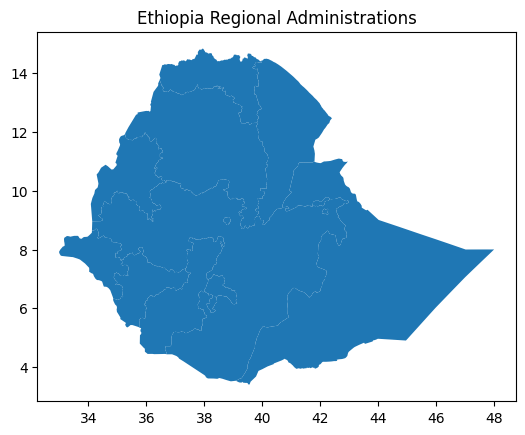

In [3]:
# Define Ethiopia Region and Load Shapefiles
ethiopia_shapefile = r"data\shapefiles\eth_admbnda_adm0_csa_bofedb_itos_2021.shp"
regional_shapefile = r"data/shapefiles/eth_admbnda_adm1_csa_bofedb_2021.shp"

# Verify the existence of shapefiles
if not os.path.exists(ethiopia_shapefile):
    raise FileNotFoundError(f"Ethiopia shapefile not found: {ethiopia_shapefile}")
if not os.path.exists(regional_shapefile):
    raise FileNotFoundError(f"Regional shapefile not found: {regional_shapefile}")

# Load shapefiles
ethiopia = gpd.read_file(ethiopia_shapefile)
print("Ethiopia shapefile loaded successfully.")

regions = gpd.read_file(regional_shapefile)
print("Regional shapefile loaded successfully.")

# Check available columns in the regional shapefile
if 'ADM1_EN' in regions.columns:
    print("ADM1_EN column found. Proceeding with filtering.")
else:
    raise ValueError("ADM1_EN column not found in the regional shapefile. Please verify the file structure.")

regions.plot()
plt.title("Ethiopia Regional Administrations")
plt.show()

In [ ]:
# Load Leader Birth Region Data
leader_birth_regions_file = "data/tabular/leader_birth_regions.csv"

# Verify the existence of the leader birth regions file
if not os.path.exists(leader_birth_regions_file):
    raise FileNotFoundError(f"Leader birth regions file not found: {leader_birth_regions_file}")

# Load the leader birth regions data
try:
    leader_birth_regions = pd.read_csv(leader_birth_regions_file)
    print("Leader birth region data loaded successfully.")
except pd.errors.EmptyDataError:
    raise ValueError("Leader birth regions file is empty. Please check the file content.")

# Ensure 'is_leader_region' column exists
if 'is_leader_region' not in leader_birth_regions.columns:
    raise ValueError("The column 'is_leader_region' is missing in the leader birth regions data.")
else:
    print("Column 'is_leader_region' exists.")

# Debugging: Display the first few rows of the dataframe
print("Preview of leader birth regions data:")
print(leader_birth_regions.head())

Leader birth region data loaded successfully.


ValueError: The column 'is_leader_region' is missing in the leader birth regions data.

In [ ]:
# Define Ethiopia Region in Google Earth Engine
ethiopia_regions = ee.FeatureCollection('FAO/GAUL/2015/level1')\
    .filter(ee.Filter.eq('ADM0_NAME', 'Ethiopia'))

# Load and Process Nighttime Lights (DMSP-OLS)
dmsp = ee.ImageCollection('NOAA/DMSP-OLS/NIGHTTIME_LIGHTS')\
    .filterDate('1992-01-01', '2013-12-31')\
    .select('stable_lights')\
    .map(lambda image: image.divide(63).rename('normalized_dmsp'))\
    .map(lambda image: image.clip(ethiopia_regions))

# Load and Process Nighttime Lights (VIIRS)
viirs = ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMCFG')\
    .filterDate('2012-01-01', '2025-12-31')\
    .select('avg_rad')\
    .map(lambda image: image.divide(100).rename('normalized_viirs'))\
    .map(lambda image: image.clip(ethiopia_regions))

# Calculate Mean DMSP and VIIRS
mean_dmsp = dmsp.mean()
mean_viirs = viirs.mean()

# Export Mean DMSP and VIIRS to CSV
mean_dmsp_task = ee.batch.Export.table.toDrive(
    collection=ethiopia_regions.map(lambda region: region.set('mean_dmsp', mean_dmsp.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region.geometry(),
        scale=1000
    ).get('normalized_dmsp'))),
    description='Ethiopia_Mean_DMSP',
    fileFormat='CSV'
)

mean_viirs_task = ee.batch.Export.table.toDrive(
    collection=ethiopia_regions.map(lambda region: region.set('mean_viirs', mean_viirs.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region.geometry(),
        scale=1000
    ).get('normalized_viirs'))),
    description='Ethiopia_Mean_VIIRS',
    fileFormat='CSV'
)

mean_dmsp_task.start()
mean_viirs_task.start()

print("Export tasks for DMSP and VIIRS have been started. Check your Google Drive for results.")

# Add follow-up to check task status
def check_task_status(task):
    status = task.status()
    print(f"Task {task.id} status: {status['state']}")

check_task_status(mean_dmsp_task)
check_task_status(mean_viirs_task)

Export tasks for DMSP and VIIRS have been started. Check your Google Drive for results.
Task H7FIC4NITD5NW7U6KOM6PNU5 status: READY
Task DXLZMURNYRFX4PVBR3IMLG2J status: READY


In [7]:
# Define the URL for the harmonized NTL dataset
url = "https://figshare.com/articles/dataset/Harmonized_Nighttime_Lights/9828827"

# Retry mechanism for downloading the dataset
import time
max_retries = 10  # Increased retry limit
retry_delay = 30  # Increased delay to 30 seconds

for attempt in range(max_retries):
    response = requests.get(url)

    if response.status_code == 200:
        print("Downloading harmonized NTL dataset...")
        zip_content = BytesIO(response.content)
        
        # Extract the zip file
        with zipfile.ZipFile(zip_content, 'r') as zip_ref:
            zip_ref.extractall("data/ntl")
            print("Harmonized NTL dataset downloaded and extracted successfully.")
        break
    elif response.status_code == 202:
        print(f"Attempt {attempt + 1}/{max_retries}: Dataset processing. Retrying in {retry_delay} seconds...")
        time.sleep(retry_delay)
    else:
        print(f"Failed to download dataset. HTTP Status Code: {response.status_code}")
        break
else:
    print("Max retries reached. Unable to download the dataset.")
    print("Please check the dataset's availability manually at the URL: https://figshare.com/articles/dataset/Harmonized_Nighttime_Lights/9828827")

Attempt 1/10: Dataset processing. Retrying in 30 seconds...
Attempt 2/10: Dataset processing. Retrying in 30 seconds...
Attempt 3/10: Dataset processing. Retrying in 30 seconds...
Attempt 4/10: Dataset processing. Retrying in 30 seconds...
Attempt 5/10: Dataset processing. Retrying in 30 seconds...
Attempt 6/10: Dataset processing. Retrying in 30 seconds...
Attempt 7/10: Dataset processing. Retrying in 30 seconds...
Attempt 8/10: Dataset processing. Retrying in 30 seconds...
Attempt 9/10: Dataset processing. Retrying in 30 seconds...
Attempt 10/10: Dataset processing. Retrying in 30 seconds...
Max retries reached. Unable to download the dataset.
Please check the dataset's availability manually at the URL: https://figshare.com/articles/dataset/Harmonized_Nighttime_Lights/9828827


In [8]:
# Define analysis period
START_YEAR = 2014
END_YEAR = 2019

# Define directory paths for Ethiopia
FIGURES_DIRECTORY = "figures"
TABLES_DIRECTORY = "tables"
VECTOR_DIRECTORY = "data/vector"
TABULAR_DIRECTORY = "data/tabular"
RASTER_DIRECTORY = "data/raster"

# Create directories if they do not exist
import os
for path in [FIGURES_DIRECTORY, TABLES_DIRECTORY, VECTOR_DIRECTORY, TABULAR_DIRECTORY, RASTER_DIRECTORY]:
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Created folder: {path}")

# Download VIIRS nighttime lights data for Ethiopia
import requests
import json
import glob
import gzip
import shutil

USERNAME = "your_username"  # Replace with your EOG username
PASSWORD = "your_password"  # Replace with your EOG password
CLIENT_ID = "eogdata_oidc"
CLIENT_SECRET = "2677ad81-521b-4869-8480-6d05b9e57d48"

def download_link(link):
    output_file = os.path.basename(link)
    output_file = os.path.join(RASTER_DIRECTORY, output_file)
    if os.path.isfile(output_file):
        print(f"File {output_file} already exists. Skipping download.")
        return

    params = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "username": USERNAME,
        "password": PASSWORD,
        "grant_type": "password",
    }
    token_url = "https://eogauth.mines.edu/auth/realms/master/protocol/openid-connect/token"
    response = requests.post(token_url, data=params)
    if response.status_code != 200:
        raise ConnectionError(f"Failed to authenticate. Status code: {response.status_code}")
    access_token_dict = json.loads(response.text)
    access_token = access_token_dict.get("access_token")
    headers = {"Authorization": f"Bearer {access_token}"}
    response = requests.get(link, headers=headers)
    if response.status_code != 200:
        raise ConnectionError(f"Failed to download file. Status code: {response.status_code}")

    with open(output_file, "wb") as f:
        f.write(response.content)
    print(f"File {output_file} downloaded successfully.")

base_url = "https://eogdata.mines.edu/nighttime_light/annual/v21/{}/"
for year in range(START_YEAR, END_YEAR + 1):
    url = f"https://eogdata.mines.edu/nighttime_light/annual/v21/{year}/VNL_v21_npp_{year}_global_vcmslcfg_c202205302300.median_masked.dat.tif.gz"
    try:
        download_link(url)
    except ConnectionError as e:
        print(f"Error downloading data for year {year}: {e}")

# Extract downloaded VIIRS data
current_dir = os.getcwd()
for file in glob.glob(os.path.join(current_dir, RASTER_DIRECTORY, "*.gz")):
    try:
        with gzip.open(file, "rb") as compressed_file, open(file[:-3], "wb") as extracted_file:
            shutil.copyfileobj(compressed_file, extracted_file)
        os.remove(file)
        print(f"Successfully extracted: {file}")
    except Exception as e:
        print(f"Error extracting file {file}: {e}")
print("Successfully extracted all .gz files!")

File data/raster\VNL_v21_npp_2014_global_vcmslcfg_c202205302300.median_masked.dat.tif.gz already exists. Skipping download.
File data/raster\VNL_v21_npp_2015_global_vcmslcfg_c202205302300.median_masked.dat.tif.gz already exists. Skipping download.
File data/raster\VNL_v21_npp_2016_global_vcmslcfg_c202205302300.median_masked.dat.tif.gz already exists. Skipping download.
File data/raster\VNL_v21_npp_2017_global_vcmslcfg_c202205302300.median_masked.dat.tif.gz already exists. Skipping download.
File data/raster\VNL_v21_npp_2018_global_vcmslcfg_c202205302300.median_masked.dat.tif.gz already exists. Skipping download.
File data/raster\VNL_v21_npp_2019_global_vcmslcfg_c202205302300.median_masked.dat.tif.gz already exists. Skipping download.
Error extracting file c:\Users\Lenovo\Desktop\NMBU_MINA\Abrish Research\NTL\data/raster\VNL_v21_npp_2014_global_vcmslcfg_c202205302300.median_masked.dat.tif.gz: Not a gzipped file (b'<!')
Error extracting file c:\Users\Lenovo\Desktop\NMBU_MINA\Abrish Resea

In [9]:
# Prepare the Environment and Data for Processing
# Define directories for data storage
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
NTL_DIR = os.path.join(DATA_DIR, "ntl")
VECTOR_DIR = os.path.join(DATA_DIR, "vector")
TABULAR_DIR = os.path.join(DATA_DIR, "tabular")

# Create directories if they do not exist
for directory in [DATA_DIR, NTL_DIR, VECTOR_DIR, TABULAR_DIR]:
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")

# Verify the downloaded files
if not os.listdir(NTL_DIR):
    raise FileNotFoundError("No files found in the NTL directory. Please ensure the harmonized NTL dataset is downloaded.")

print("Downloaded files:", os.listdir(NTL_DIR))

# Load Ethiopia shapefile
ethiopia_shapefile = os.path.join(VECTOR_DIR, "eth_admbnda_adm1_csa_bofedb_2021.shp")

if not os.path.exists(ethiopia_shapefile):
    raise FileNotFoundError(f"Ethiopia shapefile not found: {ethiopia_shapefile}")

ethiopia = gpd.read_file(ethiopia_shapefile)
print("Ethiopia shapefile loaded successfully.")

# Check available columns in the shapefile
if 'ADM1_EN' in ethiopia.columns:
    print("ADM1_EN column found. Proceeding with filtering.")
else:
    raise ValueError("ADM1_EN column not found. Please verify the shapefile structure.")

FileNotFoundError: No files found in the NTL directory. Please ensure the harmonized NTL dataset is downloaded.

Ethiopia shapefile loaded successfully.
Leader birth region data loaded successfully.
Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_1992_calDMSP.tif


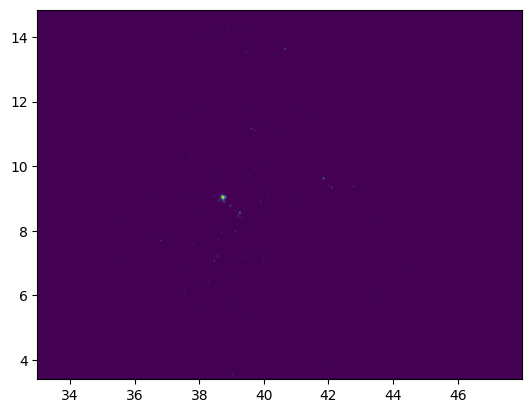

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_1993_calDMSP.tif


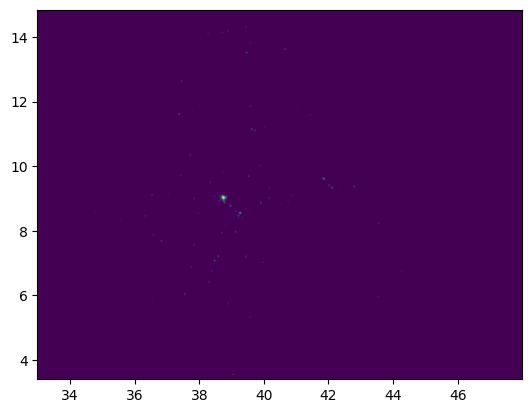

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_1994_calDMSP.tif


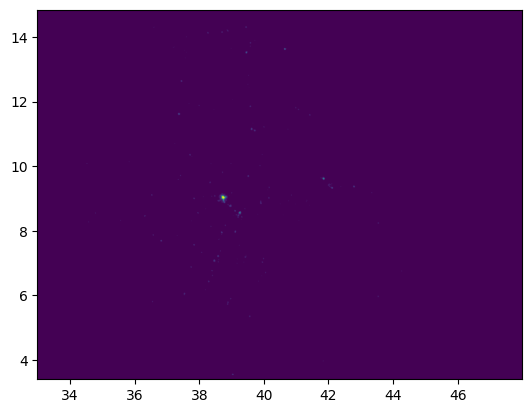

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_1995_calDMSP.tif


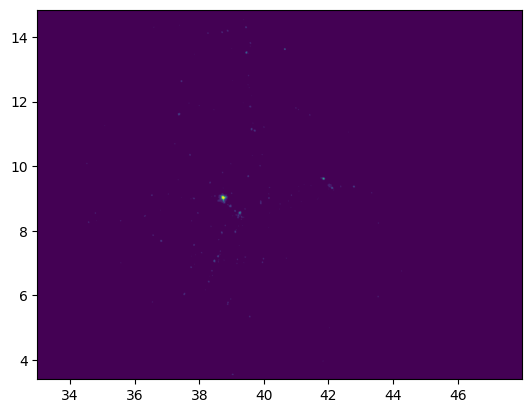

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_1996_calDMSP.tif


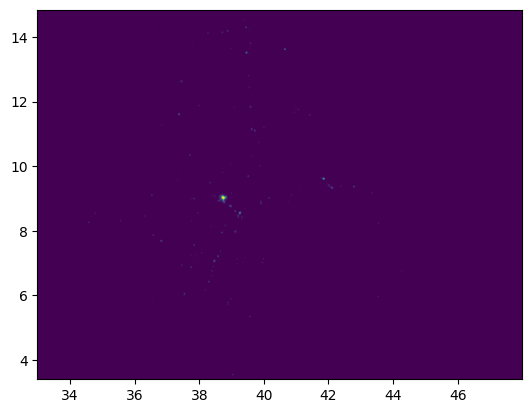

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_1997_calDMSP.tif


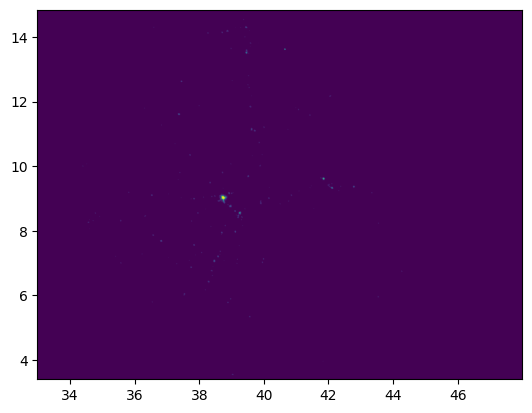

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_1998_calDMSP.tif


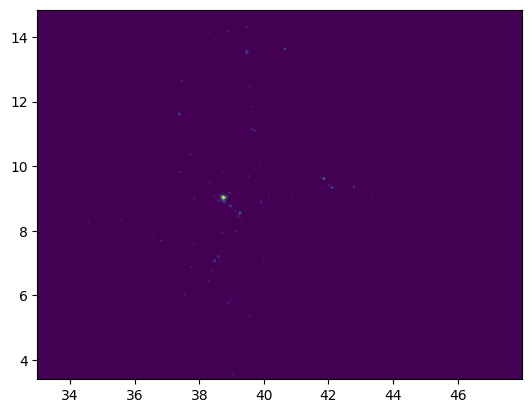

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_1999_calDMSP.tif


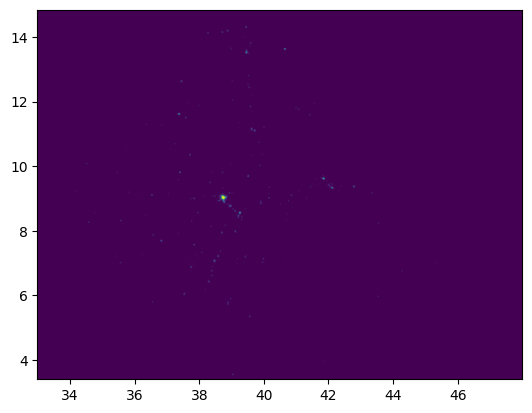

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2000_calDMSP.tif


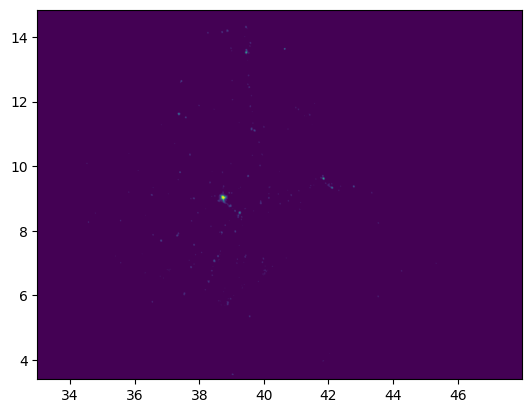

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2001_calDMSP.tif


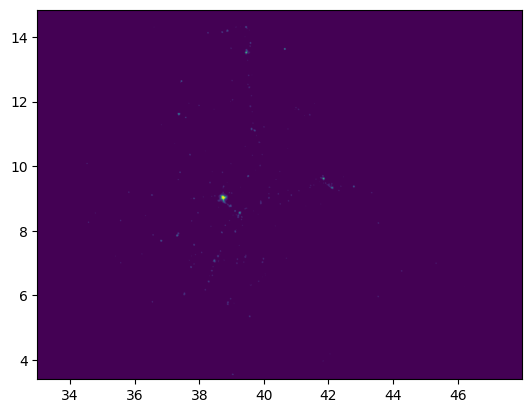

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2002_calDMSP.tif


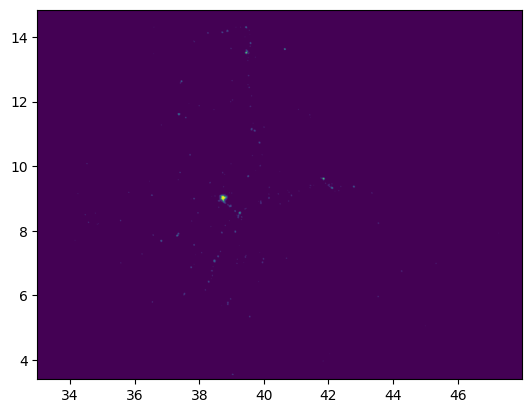

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2003_calDMSP.tif


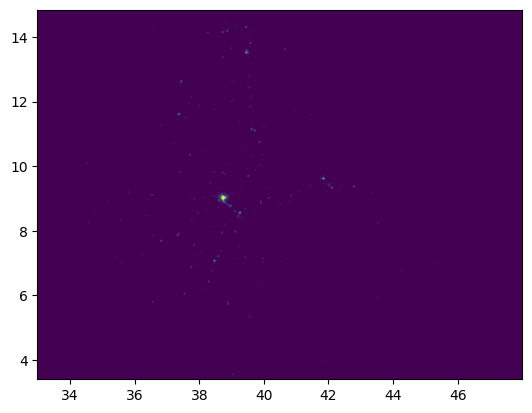

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2004_calDMSP.tif


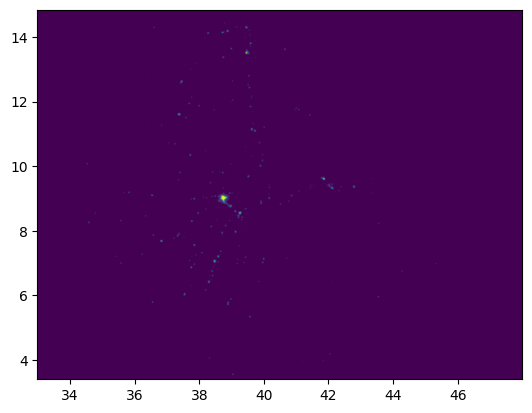

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2005_calDMSP.tif


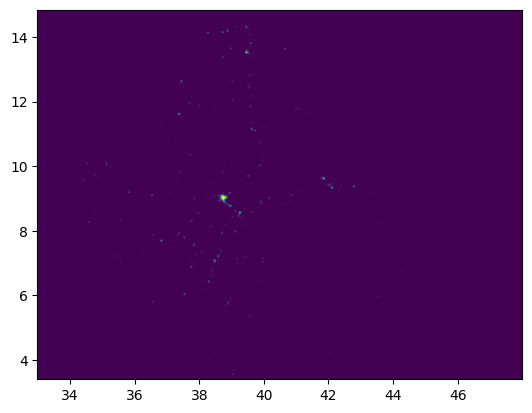

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2006_calDMSP.tif


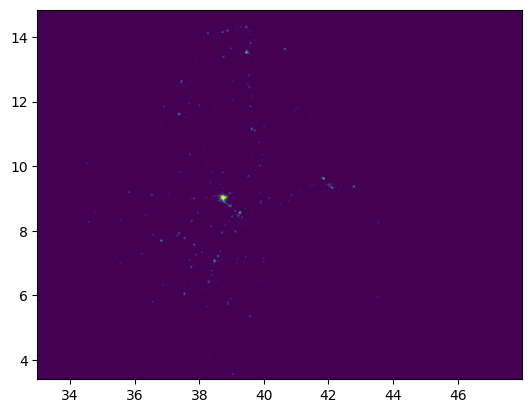

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2007_calDMSP.tif


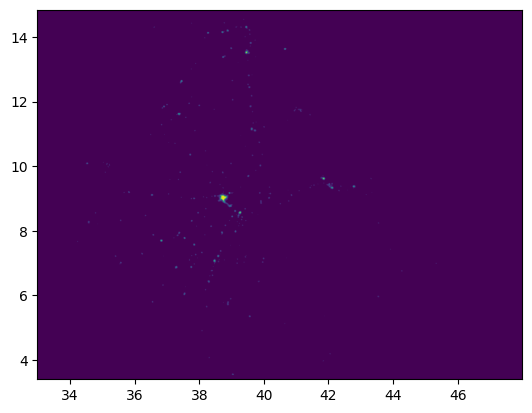

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2008_calDMSP.tif


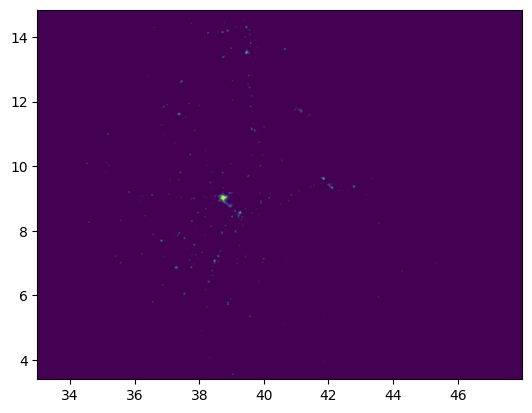

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2009_calDMSP.tif


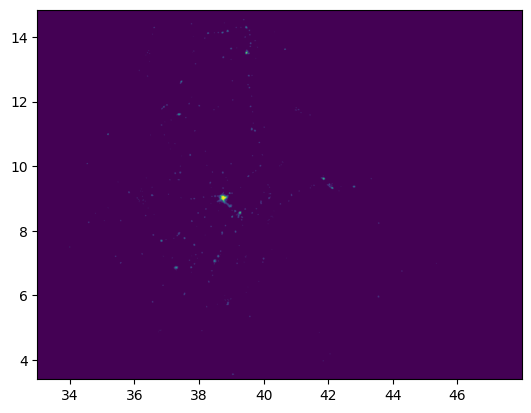

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2010_calDMSP.tif


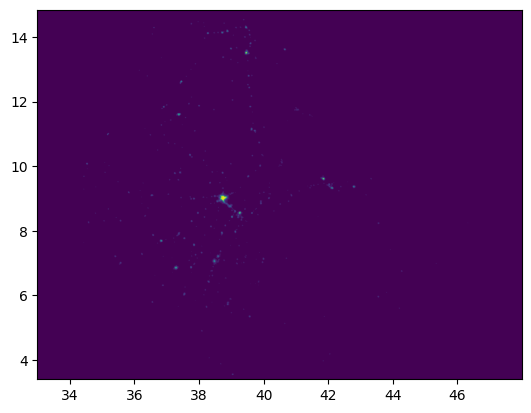

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2011_calDMSP.tif


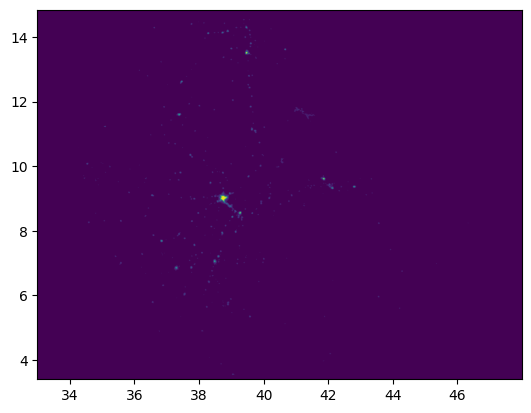

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2012_calDMSP.tif


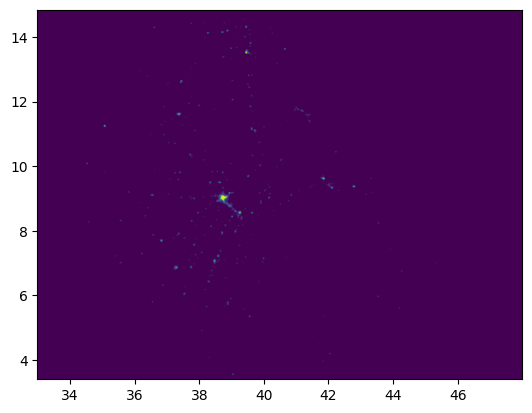

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2013_calDMSP.tif


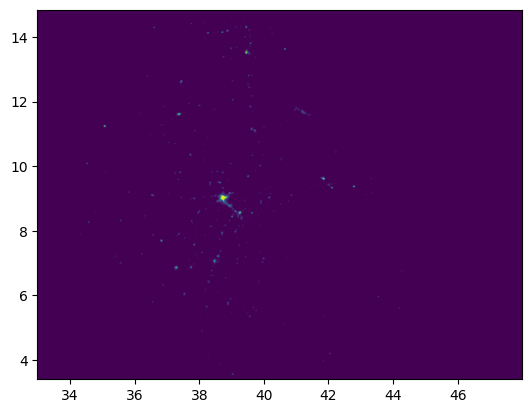

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2014_simVIIRS.tif


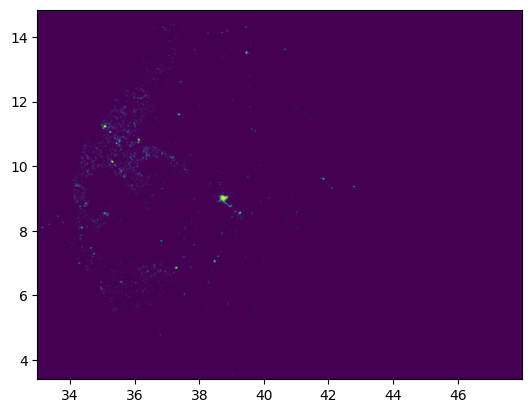

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2015_simVIIRS.tif


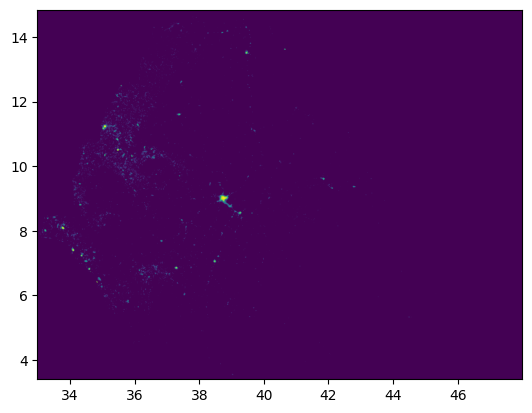

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2016_simVIIRS.tif


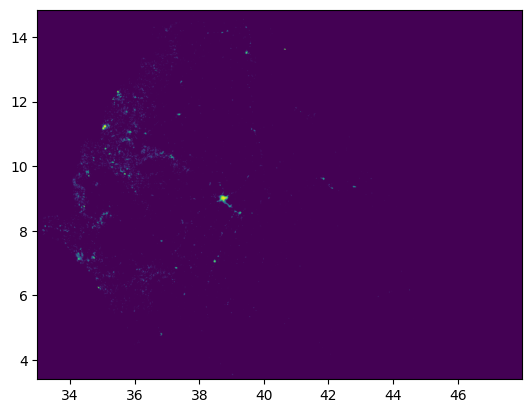

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2017_simVIIRS.tif


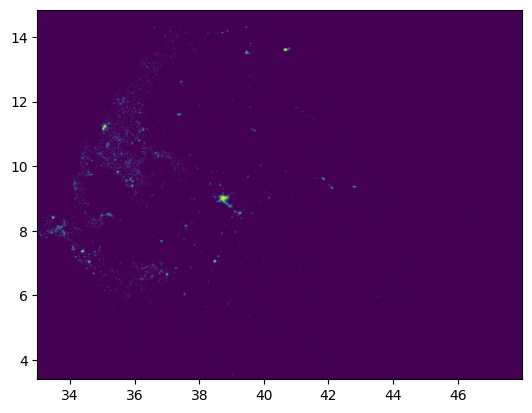

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2018_simVIIRS.tif


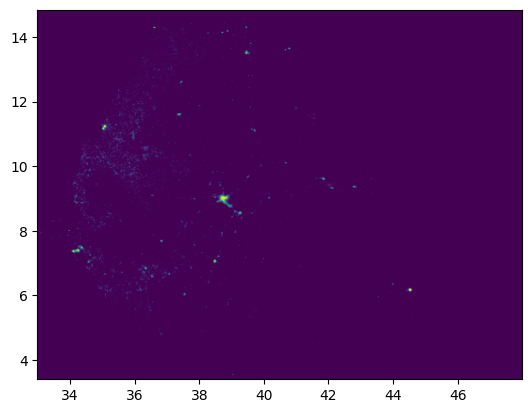

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2019_simVIIRS.tif


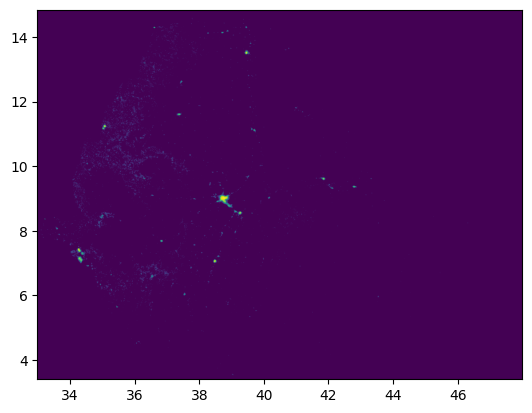

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2020_simVIIRS.tif


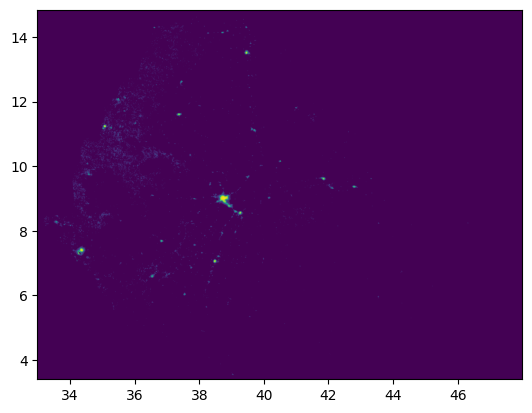

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2021_simVIIRS.tif


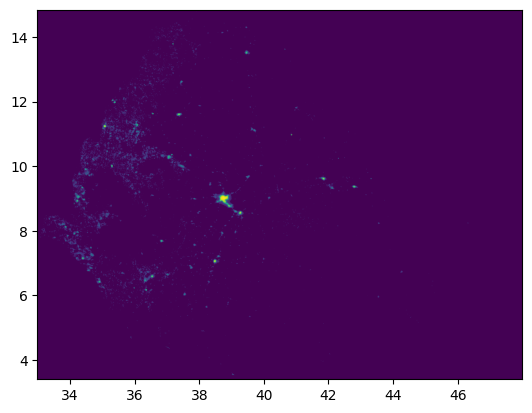

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2022_simVIIRS.tif


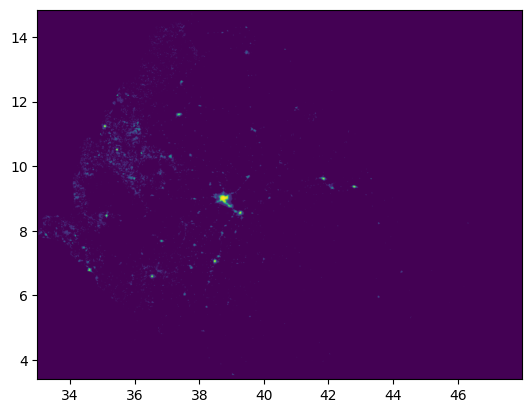

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2023_simVIIRS.tif


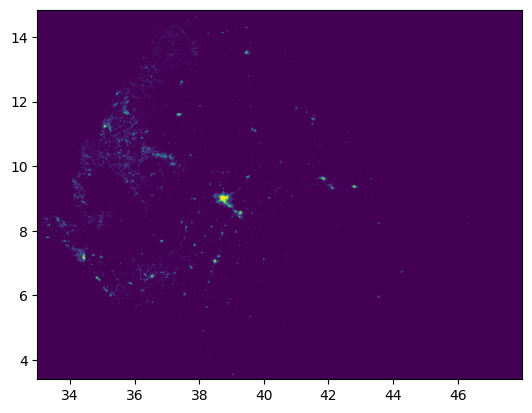

Processing clipped file: data/raster/clipped\Harmonized_DN_NTL_2024_simVIIRS.tif


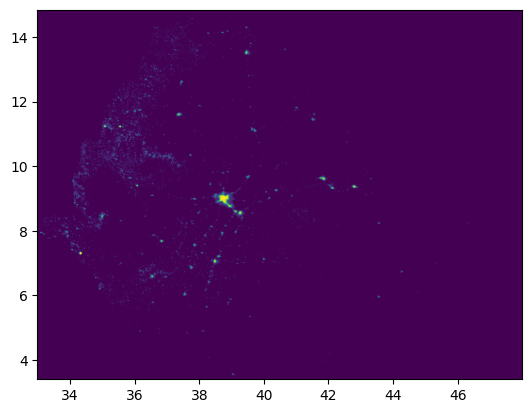

c:\Users\Lenovo\Desktop\NMBU_MINA\Abrish Research\NTL\.venv\Lib\site-packages\rasterstats\io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


Zonal statistics calculated successfully.


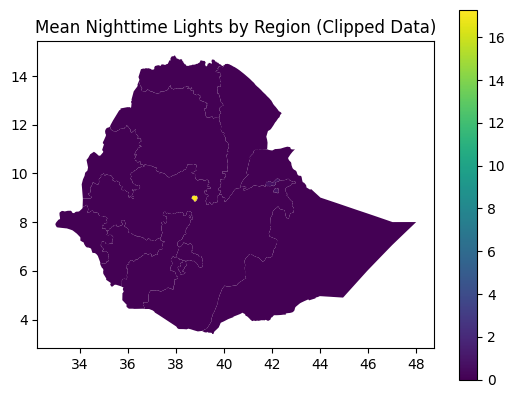

In [16]:
# Load and process clipped harmonized NTL data
import rasterio
import glob
import os
import pandas as pd
from rasterio.plot import show
from rasterio.errors import RasterioIOError
from geopandas import read_file
from shapely.geometry import box
from geopandas import GeoDataFrame
from rasterstats import zonal_stats
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Define paths
VECTOR_DIR = "data/vector"
TABULAR_DIR = "data/tabular"
CLIPPED_RASTER_DIR = "data/raster/clipped"
SHAPEFILE_DIR = "data/shapefiles"

# Load Ethiopia shapefiles
ethiopia_shapefile = os.path.join(SHAPEFILE_DIR, "eth_admbnda_adm1_csa_bofedb_2021.shp")
ethiopia = gpd.read_file(ethiopia_shapefile)
print("Ethiopia shapefile loaded successfully.")

# Load leader birth region data
leader_birth_regions_file = os.path.join(TABULAR_DIR, "leader_birth_regions.csv")
leader_birth_regions = pd.read_csv(leader_birth_regions_file)
print("Leader birth region data loaded successfully.")

# Process clipped harmonized NTL data
clipped_ntl_files = glob.glob(os.path.join(CLIPPED_RASTER_DIR, "Harmonized_DN_NTL_*.tif"))
for ntl_file in clipped_ntl_files:
    try:
        with rasterio.open(ntl_file) as src:
            print(f"Processing clipped file: {ntl_file}")
            show(src)
    except RasterioIOError as e:
        print(f"Error opening clipped file {ntl_file}: {e}")

# Perform zonal statistics on clipped data
stats = zonal_stats(ethiopia, clipped_ntl_files[0], stats="mean")
ethiopia["mean_ntl"] = [stat["mean"] for stat in stats]
print("Zonal statistics calculated successfully.")

# Plot results
ethiopia.plot(column="mean_ntl", legend=True)
plt.title("Mean Nighttime Lights by Region (Clipped Data)")
plt.show()

In [14]:
# Clip global raster files to Ethiopia boundary
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import os
import glob
 
# Define paths
RASTER_DIR = "data/raster"
CLIPPED_RASTER_DIR = "data/raster/clipped"
SHAPEFILE_DIR = "data/shapefiles"
 
# Load Ethiopia shapefile
ethiopia_shapefile = os.path.join(SHAPEFILE_DIR, "eth_admbnda_adm1_csa_bofedb_2021.shp")
ethiopia = gpd.read_file(ethiopia_shapefile)
ethiopia_geometry = [ethiopia.unary_union]
 
# Create directory for clipped rasters if it doesn't exist
if not os.path.exists(CLIPPED_RASTER_DIR):
    os.makedirs(CLIPPED_RASTER_DIR)
 
# Clip each raster file to Ethiopia boundary
raster_files = glob.glob(os.path.join(RASTER_DIR, "*.tif"))
for raster_file in raster_files:
    try:
        with rasterio.open(raster_file) as src:
            print(f"Clipping file: {raster_file}")
            out_image, out_transform = mask(src, ethiopia_geometry, crop=True)
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform
            })
            clipped_raster_path = os.path.join(CLIPPED_RASTER_DIR, os.path.basename(raster_file))
            with rasterio.open(clipped_raster_path, "w", **out_meta) as dest:
                dest.write(out_image)
            print(f"Clipped raster saved to: {clipped_raster_path}")
    except Exception as e:
        print(f"Error processing file {raster_file}: {e}")
 
print("All raster files have been clipped to Ethiopia boundary.")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20880\2457469933.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ethiopia_geometry = [ethiopia.unary_union]


Clipping file: data/raster\DN_NTL_2013_simVIIRS.tif
Clipped raster saved to: data/raster/clipped\DN_NTL_2013_simVIIRS.tif
Clipping file: data/raster\Harmonized_DN_NTL_1992_calDMSP.tif
Clipped raster saved to: data/raster/clipped\Harmonized_DN_NTL_1992_calDMSP.tif
Clipping file: data/raster\Harmonized_DN_NTL_1993_calDMSP.tif
Clipped raster saved to: data/raster/clipped\Harmonized_DN_NTL_1993_calDMSP.tif
Clipping file: data/raster\Harmonized_DN_NTL_1994_calDMSP.tif
Clipped raster saved to: data/raster/clipped\Harmonized_DN_NTL_1994_calDMSP.tif
Clipping file: data/raster\Harmonized_DN_NTL_1995_calDMSP.tif
Clipped raster saved to: data/raster/clipped\Harmonized_DN_NTL_1995_calDMSP.tif
Clipping file: data/raster\Harmonized_DN_NTL_1996_calDMSP.tif
Clipped raster saved to: data/raster/clipped\Harmonized_DN_NTL_1996_calDMSP.tif
Clipping file: data/raster\Harmonized_DN_NTL_1997_calDMSP.tif
Clipped raster saved to: data/raster/clipped\Harmonized_DN_NTL_1997_calDMSP.tif
Clipping file: data/raster

In [15]:
# Preprocess unsupported raster files to GeoTIFF format
import subprocess
 
# Define a function to convert raster files to GeoTIFF
def convert_to_geotiff(input_file, output_file):
    try:
        subprocess.run([
            "gdal_translate",
            "-of", "GTiff",
            input_file,
            output_file
        ], check=True)
        print(f"Converted {input_file} to GeoTIFF format: {output_file}")
    except subprocess.CalledProcessError as e:
        print(f"Error converting {input_file} to GeoTIFF: {e}")
 
# Process raster files and convert unsupported formats
converted_files = []
for raster_file in raster_files:
    try:
        with rasterio.open(raster_file) as src:
            # If the file opens successfully, no conversion is needed
            print(f"File {raster_file} is already in a supported format.")
    except rasterio.errors.RasterioIOError:
        # Convert unsupported files to GeoTIFF
        output_file = os.path.join(RASTER_DIR, f"converted_{os.path.basename(raster_file)}")
        convert_to_geotiff(raster_file, output_file)
        converted_files.append(output_file)
 
# Add converted files to the list of raster files for clipping
raster_files.extend(converted_files)
 
# Re-run the clipping process for all raster files (including converted ones)
for raster_file in raster_files:
    try:
        with rasterio.open(raster_file) as src:
            print(f"Clipping file: {raster_file}")
            out_image, out_transform = mask(src, ethiopia_geometry, crop=True)
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform
            })
            clipped_raster_path = os.path.join(CLIPPED_RASTER_DIR, os.path.basename(raster_file))
            with rasterio.open(clipped_raster_path, "w", **out_meta) as dest:
                dest.write(out_image)
            print(f"Clipped raster saved to: {clipped_raster_path}")
    except Exception as e:
        print(f"Error processing file {raster_file}: {e}")
 
print("All raster files have been processed and clipped to Ethiopia boundary.")

File data/raster\DN_NTL_2013_simVIIRS.tif is already in a supported format.
File data/raster\Harmonized_DN_NTL_1992_calDMSP.tif is already in a supported format.
File data/raster\Harmonized_DN_NTL_1993_calDMSP.tif is already in a supported format.
File data/raster\Harmonized_DN_NTL_1994_calDMSP.tif is already in a supported format.
File data/raster\Harmonized_DN_NTL_1995_calDMSP.tif is already in a supported format.
File data/raster\Harmonized_DN_NTL_1996_calDMSP.tif is already in a supported format.
File data/raster\Harmonized_DN_NTL_1997_calDMSP.tif is already in a supported format.
File data/raster\Harmonized_DN_NTL_1998_calDMSP.tif is already in a supported format.
File data/raster\Harmonized_DN_NTL_1999_calDMSP.tif is already in a supported format.
File data/raster\Harmonized_DN_NTL_2000_calDMSP.tif is already in a supported format.
File data/raster\Harmonized_DN_NTL_2001_calDMSP.tif is already in a supported format.
File data/raster\Harmonized_DN_NTL_2002_calDMSP.tif is already i

FileNotFoundError: [WinError 2] The system cannot find the file specified

In [ ]:
# Extract NTL data for each regional state and Ethiopia as a whole
import pandas as pd

# Define output file paths
regional_ntl_output = os.path.join(TABULAR_DIR, "regional_ntl_panel_data.xlsx")
ethiopia_ntl_output = os.path.join(TABULAR_DIR, "ethiopia_ntl_data.xlsx")

# Extract NTL data for each regional state
regional_ntl_data = []
for region in ethiopia.itertuples():
    region_name = region.ADM1_EN
    geometry = region.geometry
    stats = zonal_stats(geometry, clipped_ntl_files, stats="mean", geojson_out=True)
    for year, stat in enumerate(stats, start=START_YEAR):
        regional_ntl_data.append({
            "Region": region_name,
            "Year": year,
            "Mean_NTL": stat["properties"]["mean"]
        })

# Save regional NTL data to Excel
regional_ntl_df = pd.DataFrame(regional_ntl_data)
regional_ntl_df.to_excel(regional_ntl_output, index=False)
print(f"Regional NTL panel data saved to: {regional_ntl_output}")

# Extract NTL data for Ethiopia as a whole
ethiopia_ntl_data = []
for year, ntl_file in enumerate(clipped_ntl_files, start=START_YEAR):
    with rasterio.open(ntl_file) as src:
        stats = src.read(1).mean()
        ethiopia_ntl_data.append({
            "Year": year,
            "Mean_NTL": stats
        })

# Save Ethiopia NTL data to Excel
ethiopia_ntl_df = pd.DataFrame(ethiopia_ntl_data)
ethiopia_ntl_df.to_excel(ethiopia_ntl_output, index=False)
print(f"Ethiopia NTL data saved to: {ethiopia_ntl_output}")